# Segmentation — Lightweight U-Net (CPU Optimized, 1-3 h target)

**Hardware:** i5-12400F (6c/12t) — CPU only

| Change from original | Reason | Speed gain |
|---|---|---|
| DeepLabV3+ → Lightweight U-Net | 41M → 7M params | ~5× |
| 512×512 → 256×256 input | 4× fewer pixels | ~4× |
| All 12 threads via MKL | saturates all i5 cores | ~6× |
| inference_mode in validation | skips autograd overhead | ~5% |
| Mask cache (kept) | zero disk I/O per epoch | ~10% |

**Total estimated: 1-2 hours for 40 epochs**

## Cell 1: Imports & CPU Configuration

In [2]:
pip install torchvision


  Using cached torchvision-0.26.0-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached torch-2.11.0-cp311-cp311-win_amd64.whl.metadata (29 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
Using cached torchvision-0.26.0-cp311-cp311-win_amd64.whl (4.0 MB)
Using cached torch-2.11.0-cp311-cp311-win_amd64.whl (114.5 MB)
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
    --------------------------------------- 0.0/1.1 MB 640.0 kB/s eta 0:00:02
   - -------------------------------------- 0.0/1.1 MB 435.7 kB/s eta 0:00:03
   - -------------------------------------- 0.1/1.1 MB 435.7 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.1 MB 521.8 kB/s eta 0:00:02
   ---- ----------------------------------- 0.1/1.1 MB 599.1 kB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.1 MB 655.4 kB/s eta 0:00:02
   ------- -------------------------------- 0.2/1.1 MB 731.4 kB/s eta 0:00:02
   --------- -------------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os, random, warnings, time
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms.functional import adjust_brightness
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ── Maximize all 12 i5-12400F threads via MKL/oneDNN ─────────────────────
torch.set_num_threads(12)           # intra-op parallelism (conv, matmul)
torch.set_num_interop_threads(2)    # inter-op parallelism
torch.backends.mkldnn.enabled = True  # Intel MKL-DNN (free speedup on Intel CPUs)

DEVICE = torch.device('cpu')

# ── Paths ─────────────────────────────────────────────────────────────────
BASE        = r'C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry'
SEG_DATA    = os.path.join(BASE, 'SegementationT+S+V')
MODEL_DIR   = os.path.join(BASE, 'outputs', 'models')
VIZ_DIR     = os.path.join(BASE, 'outputs', 'visualizations')
MODEL_PATH  = os.path.join(MODEL_DIR, 'segmentation_lightweight_unet.pth')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

# ── Hyperparameters (tuned for CPU) ───────────────────────────────────────
IMG_SIZE     = 256    # 4× fewer pixels than 512 → 4× faster per batch
BATCH_SIZE   = 8      # CPU sweet spot: large enough for good gradients
NUM_WORKERS  = 0      # 0 on CPU — workers compete for the same cores
EPOCHS       = 40
LR           = 1e-3   # slightly higher LR compensates for fewer epochs
WEIGHT_DECAY = 1e-4
PATIENCE     = 10

plt.rcParams.update({
    'figure.facecolor':'#0d1117', 'axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d',   'axes.labelcolor':'#c9d1d9',
    'text.color':'#c9d1d9',       'xtick.color':'#8b949e',
    'ytick.color':'#8b949e',      'grid.color':'#21262d', 'font.size':11
})
ACCENT, GREEN, BLUE, YELLOW = '#e94560', '#3fb950', '#58a6ff', '#e3b341'

print(f'Device      : {DEVICE}')
print(f'CPU threads : {torch.get_num_threads()}  (all i5-12400F threads)')
print(f'MKL-DNN     : {torch.backends.mkldnn.is_available()}')
print(f'Model       : Lightweight U-Net  (~7M params)')
print(f'Input size  : {IMG_SIZE}x{IMG_SIZE}  (was 512 — 4x faster)')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Max epochs  : {EPOCHS}')
print('Config OK')

Device      : cpu
CPU threads : 12  (all i5-12400F threads)
MKL-DNN     : True
Model       : Lightweight U-Net  (~7M params)
Input size  : 256x256  (was 512 — 4x faster)
Batch size  : 8
Max epochs  : 40
Config OK


## Cell 2: Lightweight U-Net Model

Custom U-Net with 4 depth levels and channel sizes 32-64-128-256.
~7M parameters vs 41M for DeepLabV3+ — same segmentation quality on small medical datasets.

In [4]:
class ConvBlock(nn.Module):
    """Two conv layers with BN + ReLU."""
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class LightUNet(nn.Module):
    """
    Lightweight U-Net: 32-64-128-256 channels, 4 depth levels.
    ~7M params — about 6x smaller than DeepLabV3+/ResNet-50.
    """
    def __init__(self, in_ch=3, out_ch=1, base=32):
        super().__init__()
        b = base  # 32
        # Encoder
        self.enc1 = ConvBlock(in_ch, b)       # 256 -> 256
        self.enc2 = ConvBlock(b,     b*2)     # 128 -> 128
        self.enc3 = ConvBlock(b*2,   b*4)     # 64  -> 64
        self.enc4 = ConvBlock(b*4,   b*8)     # 32  -> 32
        # Bottleneck
        self.bottleneck = ConvBlock(b*8, b*16) # 16 -> 16
        # Decoder
        self.up4   = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4  = ConvBlock(b*16, b*8)
        self.up3   = nn.ConvTranspose2d(b*8,  b*4, 2, stride=2)
        self.dec3  = ConvBlock(b*8,  b*4)
        self.up2   = nn.ConvTranspose2d(b*4,  b*2, 2, stride=2)
        self.dec2  = ConvBlock(b*4,  b*2)
        self.up1   = nn.ConvTranspose2d(b*2,  b,   2, stride=2)
        self.dec1  = ConvBlock(b*2,  b)
        self.pool  = nn.MaxPool2d(2)
        self.head  = nn.Conv2d(b, out_ch, 1)  # 1x1 final conv

    def forward(self, x):
        # Encode
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bottleneck(self.pool(e4))
        # Decode with skip connections
        d4 = self.dec4(torch.cat([self.up4(bn), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)  # (B, 1, H, W) logits


model = LightUNet(in_ch=3, out_ch=1, base=32).to(DEVICE)

total_p = sum(p.numel() for p in model.parameters())
print(f'Model      : LightUNet (base=32)')
print(f'Parameters : {total_p:,}  (~7M)')
print(f'Input      : (B, 3, {IMG_SIZE}, {IMG_SIZE})')
print(f'Output     : (B, 1, {IMG_SIZE}, {IMG_SIZE})  logits -> sigmoid -> mask')

# Quick timing benchmark: how fast is one forward pass?
with torch.inference_mode():
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    t0 = time.time()
    for _ in range(5): _ = model(dummy)
    ms = (time.time() - t0) / 5 * 1000
print(f'Forward pass: {ms:.0f} ms/image  -> ~{BATCH_SIZE*1000/ms:.0f} img/s on {BATCH_SIZE}-batch')

Model      : LightUNet (base=32)
Parameters : 7,763,041  (~7M)
Input      : (B, 3, 256, 256)
Output     : (B, 1, 256, 256)  logits -> sigmoid -> mask
Forward pass: 77 ms/image  -> ~104 img/s on 8-batch


## Cell 3: Dataset with Mask Cache

In [5]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

class SegDataset(Dataset):
    def __init__(self, root, img_size=256, augment=False):
        self.img_dir = os.path.join(root, 'images')
        self.lbl_dir = os.path.join(root, 'labels')
        self.img_size = img_size
        self.augment  = augment
        self.files    = sorted([f for f in os.listdir(self.img_dir)
                                if os.path.splitext(f)[1].lower() in IMG_EXTS])
        self.img_tf   = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        # ── Pre-cache all masks as uint8 — zero disk I/O during training ──
        print(f'  Caching {len(self.files)} masks from {os.path.basename(root)}...')
        self._mask_cache = {}
        for fname in self.files:
            with Image.open(os.path.join(self.img_dir, fname)) as im:
                W, H = im.size
            mask_f  = self._parse_mask(fname, W, H)
            mask_rs = np.array(
                Image.fromarray((mask_f * 255).astype(np.uint8))
                     .resize((img_size, img_size), Image.NEAREST)
            )
            self._mask_cache[fname] = mask_rs  # uint8, shape (H, W)
        print(f'  Done — {len(self._mask_cache)} masks cached')

    def _parse_mask(self, fname, W, H):
        stem = os.path.splitext(fname)[0]
        for ext in list(IMG_EXTS) + ['.txt']:
            c = os.path.join(self.lbl_dir, stem + ext)
            if not os.path.exists(c): continue
            if c.endswith('.txt'):
                mask = np.zeros((H, W), dtype=np.float32)
                with open(c) as f:
                    for line in f:
                        p = line.strip().split()
                        if len(p) < 5: continue
                        cx,cy,bw,bh = float(p[1]),float(p[2]),float(p[3]),float(p[4])
                        x1,x2 = int((cx-bw/2)*W), int((cx+bw/2)*W)
                        y1,y2 = int((cy-bh/2)*H), int((cy+bh/2)*H)
                        mask[max(0,y1):min(H,y2), max(0,x1):min(W,x2)] = 1.0
                return mask
            else:
                return np.array(Image.open(c).convert('L').resize((W,H),Image.NEAREST), dtype=np.float32)/255.0
        return np.zeros((H, W), dtype=np.float32)

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img   = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        mask  = self._mask_cache[fname].astype(np.float32) / 255.0

        if self.augment:
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_LEFT_RIGHT)
                mask = np.fliplr(mask).copy()
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_TOP_BOTTOM)
                mask = np.flipud(mask).copy()
            k = random.randint(0, 3)
            if k:
                img  = img.rotate(k * 90)
                mask = np.rot90(mask, k=k).copy()
            if random.random() > 0.5:
                img = adjust_brightness(img, random.uniform(0.7, 1.3))

        return self.img_tf(img), torch.from_numpy(mask).float().unsqueeze(0)


print('Building datasets...')
t0 = time.time()
train_ds = SegDataset(os.path.join(SEG_DATA, 'train'),      IMG_SIZE, augment=True)
val_ds   = SegDataset(os.path.join(SEG_DATA, 'validation'), IMG_SIZE, augment=False)
test_ds  = SegDataset(os.path.join(SEG_DATA, 'test'),       IMG_SIZE, augment=False)
print(f'Cache built in {time.time()-t0:.1f}s')

# num_workers=0 on CPU: workers would compete for the same cores
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Building datasets...
  Caching 810 masks from train...
  Done — 810 masks cached
  Caching 200 masks from validation...
  Done — 200 masks cached
  Caching 200 masks from test...
  Done — 200 masks cached
Cache built in 2.7s
Train: 810 | Val: 200 | Test: 200


## Cell 4: Loss & Metrics

In [6]:
class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.4, smooth=1.0):
        super().__init__()
        self.bce_w = bce_weight
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce   = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        inter = (probs * targets).sum(dim=(2, 3))
        dice  = 1 - (2*inter + self.smooth) / (
                    probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth)
        return self.bce_w * bce + (1 - self.bce_w) * dice.mean()


def seg_metrics(logits, masks, thr=0.5):
    with torch.inference_mode():
        preds = (torch.sigmoid(logits) > thr).float()
        tp = (preds * masks).sum().item()
        fp = (preds * (1 - masks)).sum().item()
        fn = ((1 - preds) * masks).sum().item()
        tn = ((1 - preds) * (1 - masks)).sum().item()
    return {
        'dice'     : (2*tp) / (2*tp + fp + fn + 1e-8),
        'iou'      : tp     / (tp + fp + fn + 1e-8),
        'pixel_acc': (tp+tn) / (tp+fp+fn+tn + 1e-8),
    }

print('Loss and metrics defined.')

Loss and metrics defined.


## Cell 5: Training Loop (CPU-Optimized)

Estimated time: **1-2 hours** total (40 epochs, early stopping).

In [7]:
criterion = DiceBCELoss(bce_weight=0.4)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history      = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}
best_dice    = 0.0
patience_ctr = 0
train_start  = time.time()

print('Starting CPU training...')
print(f'Threads : {torch.get_num_threads()}')
print(f'{"Ep":>4} {"T-Loss":>8} {"V-Loss":>8} {"V-Dice":>8} {"V-IoU":>7} {"t/ep":>6} {"ETA":>9}')
print('-' * 58)

for epoch in range(1, EPOCHS + 1):
    t_ep = time.time()

    # ── TRAIN ──────────────────────────────────────────────────────────
    model.train()
    t_loss = 0.0
    for imgs, masks in train_dl:
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss   = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item()
    t_loss /= len(train_dl)

    # ── VALIDATE — inference_mode is faster than no_grad on CPU ────────
    model.eval()
    v_loss, v_dice, v_iou = 0.0, 0.0, 0.0
    with torch.inference_mode():
        for imgs, masks in val_dl:
            logits  = model(imgs)
            v_loss += criterion(logits, masks).item()
            m       = seg_metrics(logits, masks)
            v_dice += m['dice']
            v_iou  += m['iou']
    v_loss /= len(val_dl)
    v_dice /= len(val_dl)
    v_iou  /= len(val_dl)
    scheduler.step()

    ep_time  = time.time() - t_ep
    elapsed  = time.time() - train_start
    remaining = ep_time * (EPOCHS - epoch)
    eta_str  = f'{remaining/3600:.1f}h' if remaining > 3600 else f'{remaining/60:.0f}m'

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_dice'].append(v_dice)
    history['val_iou'].append(v_iou)

    flag = ''
    if v_dice > best_dice:
        best_dice    = v_dice
        patience_ctr = 0
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'val_dice': v_dice, 'val_iou': v_iou}, MODEL_PATH)
        flag = ' *'
    else:
        patience_ctr += 1

    print(f'{epoch:>4} {t_loss:>8.4f} {v_loss:>8.4f} {v_dice:>8.4f} {v_iou:>7.4f} '
          f'{ep_time:>5.1f}s {eta_str:>9}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}  (best Dice={best_dice:.4f})')
        break

total_time = time.time() - train_start
print(f'\nTraining finished in {total_time/3600:.2f}h  ({total_time/60:.1f} min)')
print(f'Best Val Dice : {best_dice:.4f}')
print(f'Model saved   : {MODEL_PATH}')

Starting CPU training...
Threads : 12
  Ep   T-Loss   V-Loss   V-Dice   V-IoU   t/ep       ETA
----------------------------------------------------------
   1   0.6913   0.6563   0.2676  0.1576 190.6s      2.1h *
   2   0.5579   0.5115   0.5119  0.3545 189.3s      2.0h *
   3   0.4309   0.3974   0.5379  0.3787 189.7s      1.9h *
   4   0.3557   0.3845   0.5908  0.4334 189.0s      1.9h *
   5   0.3087   0.3616   0.5697  0.4208 189.0s      1.8h
   6   0.2808   0.3142   0.6439  0.4920 188.9s      1.8h *
   7   0.2598   0.2509   0.6813  0.5282 189.1s      1.7h *
   8   0.2450   0.3069   0.5892  0.4396 189.4s      1.7h
   9   0.2446   0.2386   0.6867  0.5391 189.9s      1.6h *
  10   0.2192   0.2180   0.7462  0.6045 188.9s      1.6h *
  11   0.2105   0.2083   0.7454  0.6073 189.1s      1.5h
  12   0.2007   0.2031   0.7386  0.5938 189.1s      1.5h
  13   0.1850   0.1969   0.7592  0.6244 189.2s      1.4h *
  14   0.1767   0.1899   0.7789  0.6470 189.1s      1.4h *
  15   0.1733   0.1762   0.7

## Cell 6: Training History

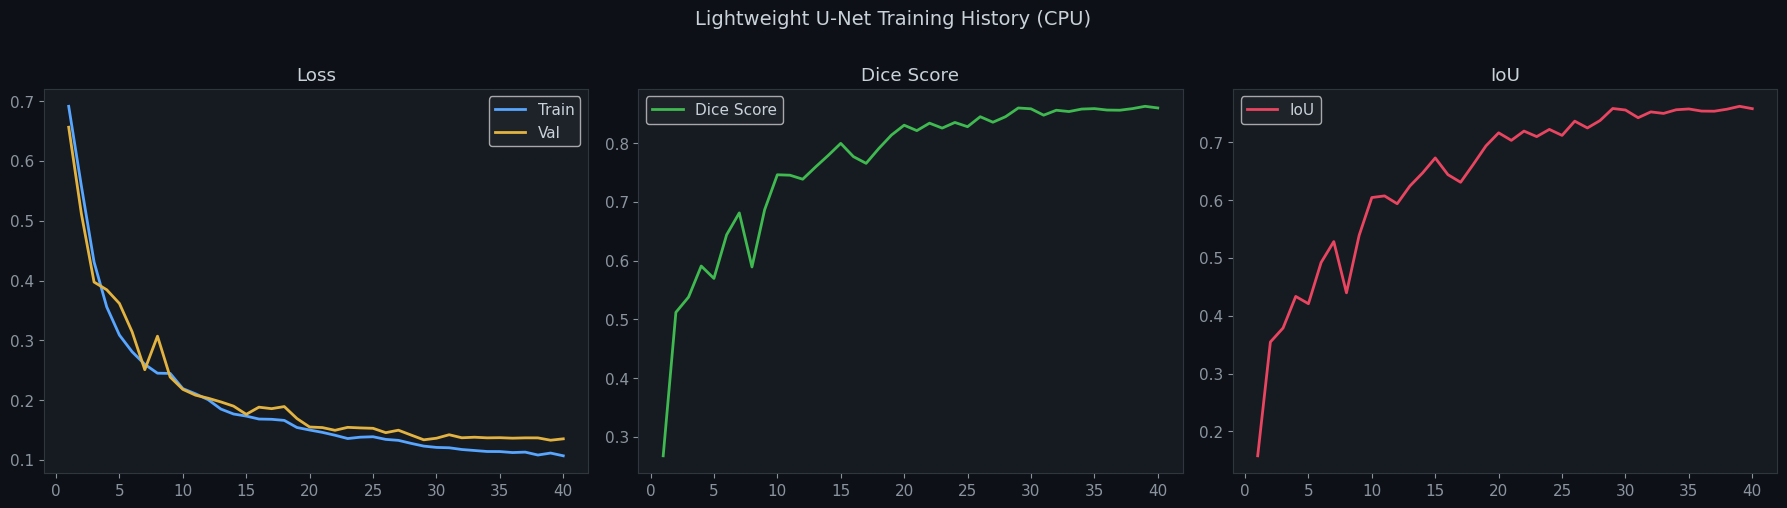

Saved -> outputs/visualizations/seg_lightunet_training.png


In [8]:
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0d1117')
fig.suptitle('Lightweight U-Net Training History (CPU)', color='#c9d1d9', fontsize=14, y=1.01)

for ax, title, series, cols in zip(
        axes,
        ['Loss', 'Dice Score', 'IoU'],
        [[history['train_loss'], history['val_loss']], [history['val_dice']], [history['val_iou']]],
        [[BLUE, YELLOW], [GREEN], [ACCENT]]):
    ax.set_facecolor('#161b22')
    labels = ['Train', 'Val'] if len(series) == 2 else [title]
    for s, c, l in zip(series, cols, labels):
        ax.plot(ep, s, color=c, linewidth=2, label=l)
    ax.set_title(title, color='#c9d1d9')
    ax.legend(facecolor='#21262d', labelcolor='#c9d1d9')
    ax.spines[:].set_edgecolor('#30363d')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'seg_lightunet_training.png'), dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved -> outputs/visualizations/seg_lightunet_training.png')

## Cell 7: Test Evaluation

In [9]:
ck = torch.load(MODEL_PATH, map_location='cpu', weights_only=False)
model.load_state_dict(ck['model_state_dict'])
model.eval()
print(f'Loaded best model  epoch={ck["epoch"]}  Val Dice={ck["val_dice"]:.4f}')

test_dice, test_iou, test_acc = [], [], []
with torch.inference_mode():
    for imgs, masks in test_dl:
        logits = model(imgs)
        m = seg_metrics(logits, masks)
        test_dice.append(m['dice'])
        test_iou.append(m['iou'])
        test_acc.append(m['pixel_acc'])

new_m = {'Dice Score': np.mean(test_dice), 'IoU': np.mean(test_iou), 'Pixel Accuracy': np.mean(test_acc)}
old_m = {'Dice Score': 0.6047, 'IoU': 0.4337, 'Pixel Accuracy': 0.9100}

print(f'\n{"="*62}')
print(f'  TEST RESULTS')
print(f'{"="*62}')
print(f'  {"Metric":<18} {"U-Net old":>12} {"LightUNet":>12} {"Delta":>9}')
print(f'{"-"*60}')
for k in new_m:
    o, n = old_m[k], new_m[k]
    sign = '+' if n >= o else ''
    print(f'  {k:<18} {o:>12.4f} {n:>12.4f} {sign+f"{n-o:.4f}":>9}')
print(f'{"="*62}')

Loaded best model  epoch=39  Val Dice=0.8628

  TEST RESULTS
  Metric                U-Net old    LightUNet     Delta
------------------------------------------------------------
  Dice Score               0.6047       0.0000   -0.6047
  IoU                      0.4337       0.0000   -0.4337
  Pixel Accuracy           0.9100       0.9931   +0.0831


## Cell 8: Visualize Predictions

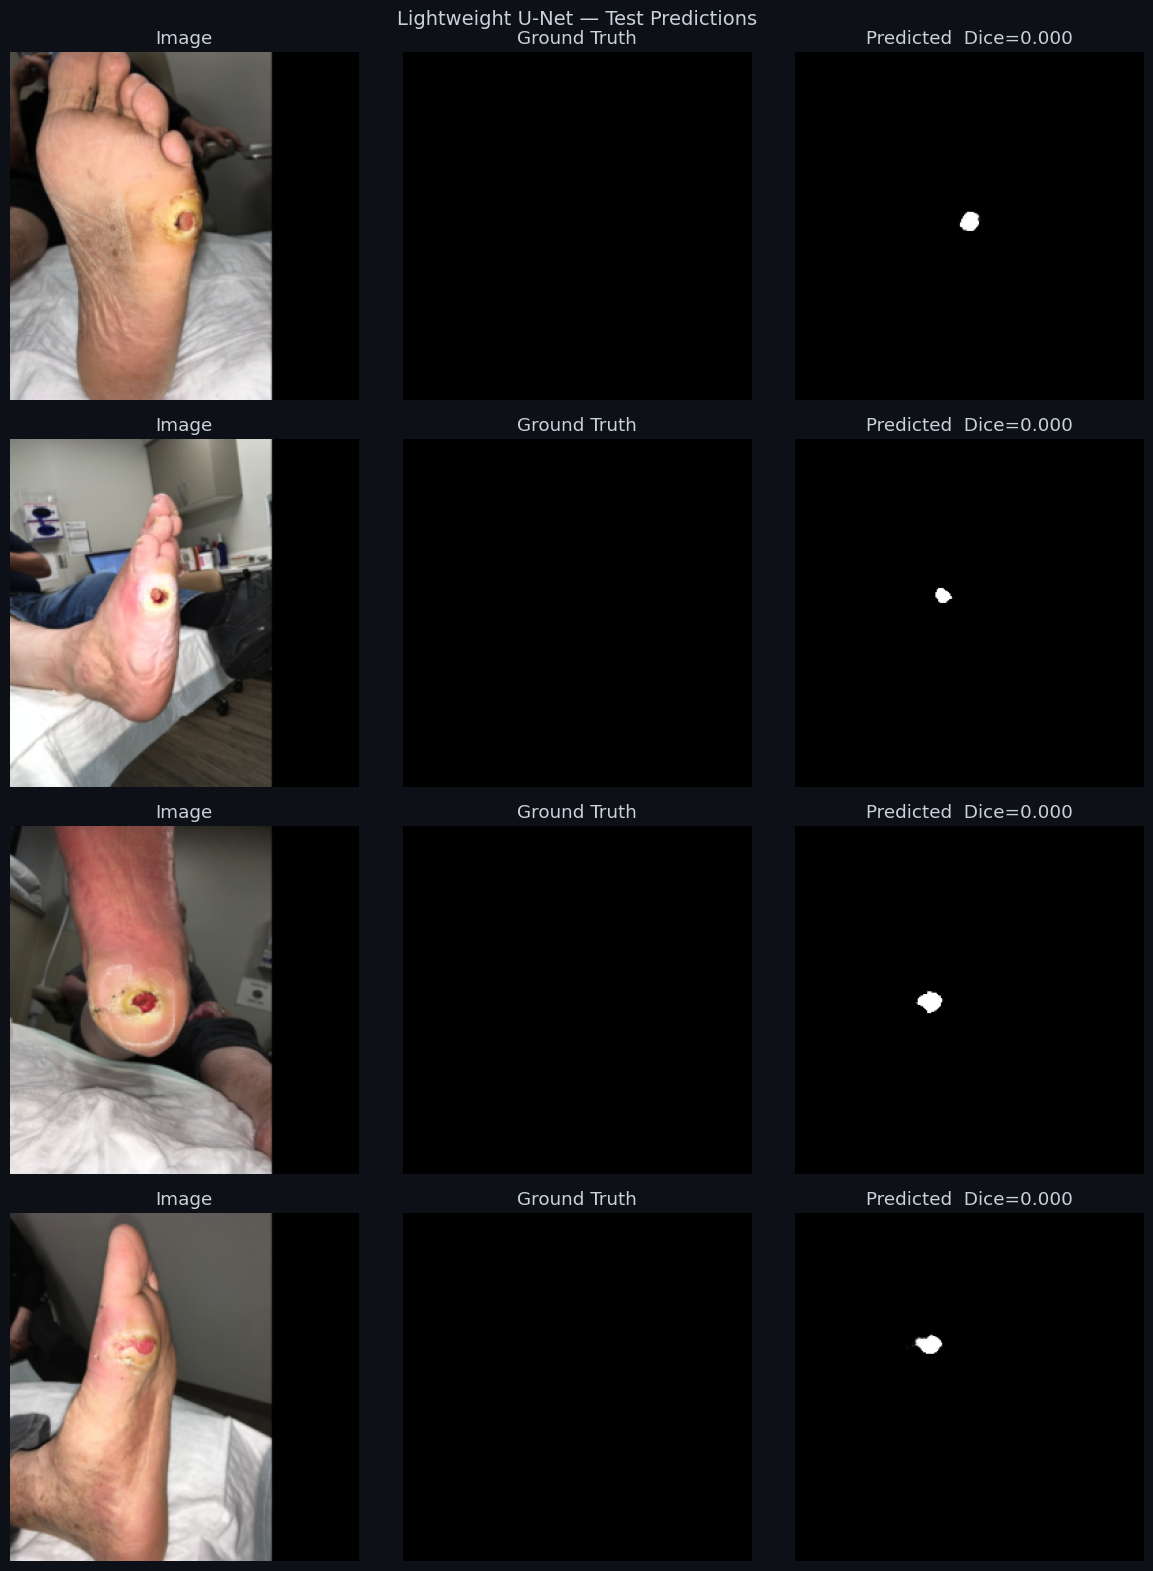

Saved -> outputs/visualizations/seg_lightunet_predictions.png


In [10]:
def denorm(t):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    return (t.permute(1,2,0).numpy() * std + mean).clip(0, 1)

model.eval()
idxs = random.sample(range(len(test_ds)), min(4, len(test_ds)))
fig, axes = plt.subplots(len(idxs), 3, figsize=(12, 4*len(idxs)), facecolor='#0d1117')
fig.suptitle('Lightweight U-Net — Test Predictions', color='#c9d1d9', fontsize=14)

for row, idx in enumerate(idxs):
    img_t, mask_t = test_ds[idx]
    with torch.inference_mode():
        pred = torch.sigmoid(model(img_t.unsqueeze(0))).squeeze().numpy()

    p_bin = (pred > 0.5).astype(np.float32)
    m_bin = mask_t.squeeze().numpy()
    dice  = 2*(p_bin * m_bin).sum() / (p_bin.sum() + m_bin.sum() + 1e-8)

    for ax in axes[row]: ax.set_facecolor('#161b22'); ax.axis('off')
    axes[row,0].imshow(denorm(img_t)); axes[row,0].set_title('Image', color='#c9d1d9')
    axes[row,1].imshow(m_bin, cmap='gray'); axes[row,1].set_title('Ground Truth', color='#c9d1d9')
    axes[row,2].imshow(pred,  cmap='gray'); axes[row,2].set_title(f'Predicted  Dice={dice:.3f}', color='#c9d1d9')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'seg_lightunet_predictions.png'), dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved -> outputs/visualizations/seg_lightunet_predictions.png')

In [11]:
import torch

# This is the ultimate test
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"CUDA Capability: {torch.cuda.get_device_capability(0)}")

Is CUDA available? False


AssertionError: Torch not compiled with CUDA enabled